HR-агентство изучает тренды на рынке труда в IT. Компания хочет провести исследование на основе данных о зарплатах в сфере Data Science за 2020–2022 годы и получить некоторые выводы.

In [416]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chi2_contingency
import numpy as np
from scipy.stats import chisquare
from scipy.stats import kruskal


In [417]:
data = pd.read_csv('data/ds_salaries.csv')

In [418]:
data.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [419]:
# задаем уровень значимости
alpha = 0.05
print('Уровень значимости alpha = {:.2f}'.format(alpha))

Уровень значимости alpha = 0.05


## Описательный анализ данных

In [420]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


В датасете 607 записей (без пропущенных значений)

Проверим данные на наличие полных дубликатов:

In [421]:
print('Количество дубликатов: {}'.format(data[data.duplicated].shape[0]))

data = data.drop_duplicates()
print('Размер таблицы после удаления дубликатов: {}'.format(data.shape))

Количество дубликатов: 0
Размер таблицы после удаления дубликатов: (607, 12)


Приведём данные к корректным типам

In [422]:
data['experience_level'] = data['experience_level'].astype('category')
data['employment_type'] = data['employment_type'].astype('category')
data['salary_currency'] = data['salary_currency'].astype('category')
data['employee_residence'] = data['employee_residence'].astype('category')
data['company_location'] = data['company_location'].astype('category')
data['company_size'] = data['company_size'].astype('category')
data['job_title'] = data['job_title'].astype('category')
data['remote_ratio'] = data['remote_ratio'].astype('category')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Unnamed: 0          607 non-null    int64   
 1   work_year           607 non-null    int64   
 2   experience_level    607 non-null    category
 3   employment_type     607 non-null    category
 4   job_title           607 non-null    category
 5   salary              607 non-null    int64   
 6   salary_currency     607 non-null    category
 7   salary_in_usd       607 non-null    int64   
 8   employee_residence  607 non-null    category
 9   remote_ratio        607 non-null    category
 10  company_location    607 non-null    category
 11  company_size        607 non-null    category
dtypes: category(8), int64(4)
memory usage: 32.6 KB


Поиск неинформативных признаков

In [423]:
low_information_cols = []

for col in data.columns:
    top_freq = data[col].value_counts(normalize=True).max()
    nunique_ratio = data[col].nunique() / data[col].count()
    if top_freq > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(top_freq * 100, 2)}% одинаковых значений')
    if nunique_ratio > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(nunique_ratio * 100, 2)}% уникальных значений')

Unnamed: 0: 100.0% уникальных значений
employment_type: 96.87% одинаковых значений


In [424]:
data = data.drop(low_information_cols, axis=1)
print(f'Результирующее число признаков {data.shape[1]}')

Результирующее число признаков 10


# Распределение зарплат в usd по всем вакансиям

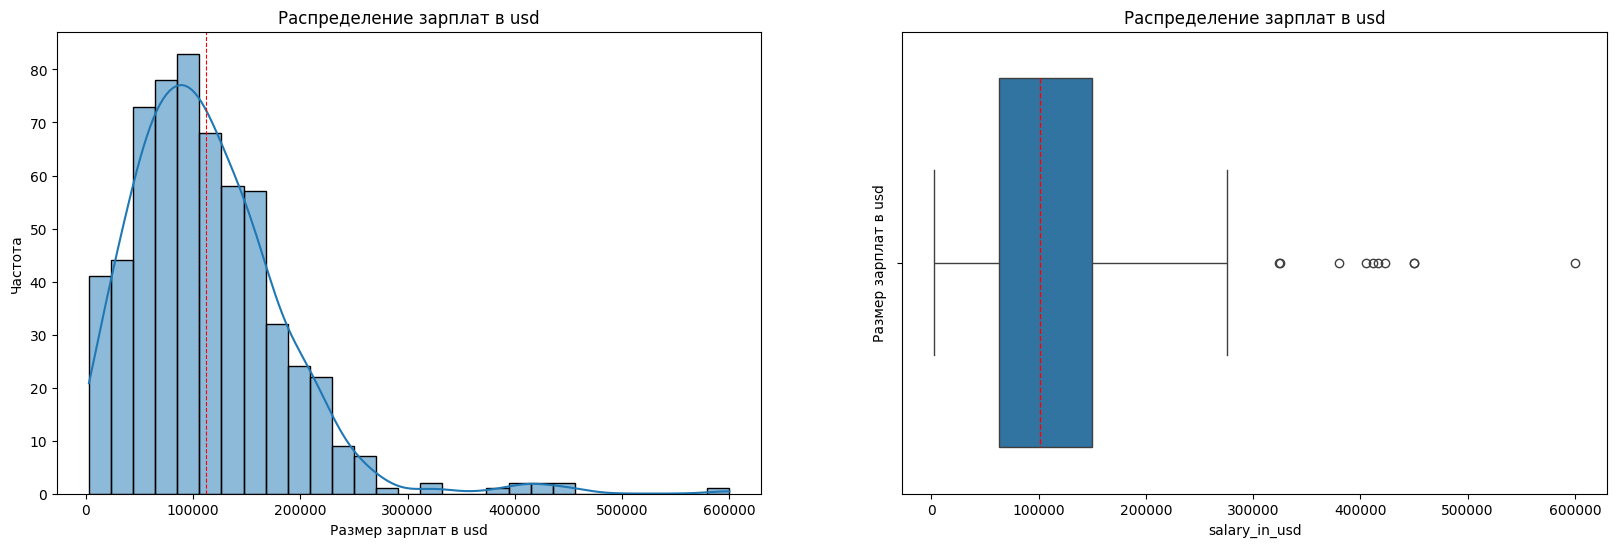

In [425]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.histplot(data['salary_in_usd'], kde=True, ax=axes[0])
axes[0].set(xlabel='Размер зарплат в usd', ylabel='Частота')
axes[0].set_title('Распределение зарплат в usd')
axes[0].axvline(data['salary_in_usd'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['salary_in_usd'], ax=axes[1], orient='h', medianprops={'color': 'red', 'linestyle': '--'})
axes[1].set(ylabel='Размер зарплат в usd')
axes[1].set_title('Распределение зарплат в usd')

plt.show()

In [426]:
data_agg = data['salary_in_usd'].describe().round(2).to_frame()
data_agg.columns = ['Зарплаты в usd']
data_agg

,Зарплаты в usd
count,607.00
mean,112297.87
std,70957.26
min,2859.00
25%,62726.00
50%,101570.00
75%,150000.00
max,600000.00


In [427]:
# проводим тест Шапиро - Уилка
_, p = stats.shapiro(data['salary_in_usd'])
print('p-value = %.2f' % (p))

if p <= alpha:
    print('Распределение зарплат в usd не нормальное')
else:
    print('распределение зарплат в usd нормальное')

p-value = 0.00
Распределение зарплат в usd не нормальное


# Распределение зарплат по должностям

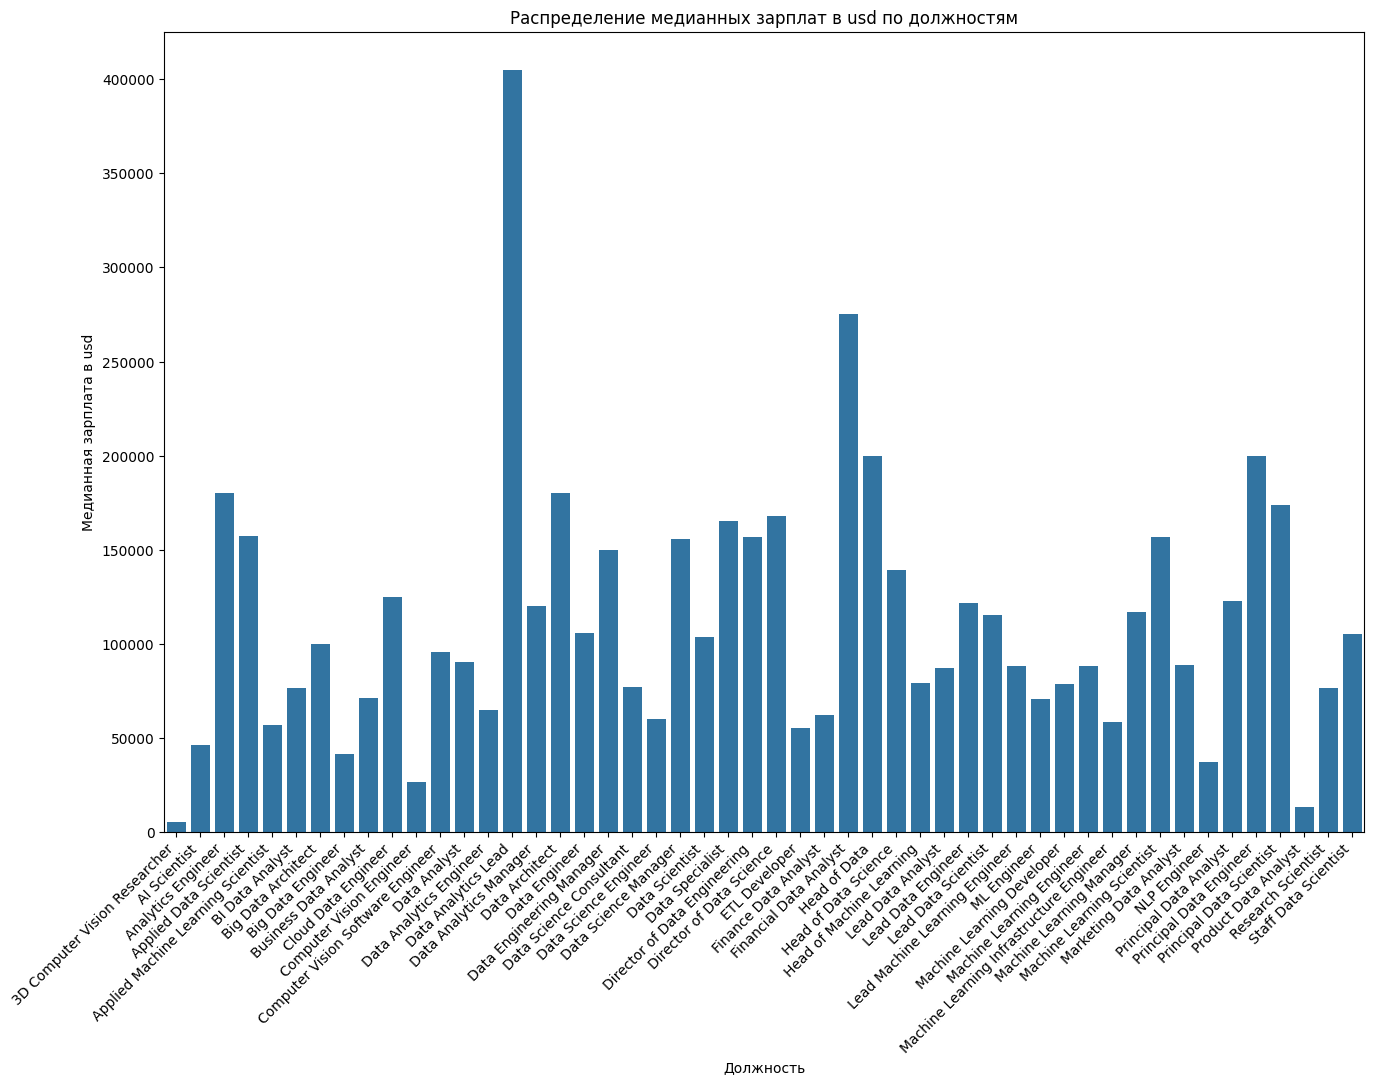

In [512]:
fig = plt.figure(figsize=(12, 8))
axes = fig.add_axes([0, 0, 1, 1])

vacancy_salary_agg = data.groupby(by='job_title', observed=True)['salary_in_usd'].median()
vacancy_salary_agg

sns.barplot(x=vacancy_salary_agg.index, y=vacancy_salary_agg.values, ax=axes)
axes.tick_params(axis='x', labelrotation=45)
plt.setp(axes.get_xticklabels(), ha='right')
axes.set(xlabel='Должность', ylabel='Медианная зарплата в usd')
axes.set_title('Распределение медианных зарплат в usd по должностям')

plt.show()

In [429]:
vacancy_salary_agg.info()

<class 'pandas.core.series.Series'>
CategoricalIndex: 50 entries, 3D Computer Vision Researcher to Staff Data Scientist
Series name: salary_in_usd
Non-Null Count  Dtype  
--------------  -----  
50 non-null     float64
dtypes: float64(1)
memory usage: 2.9 KB


## Статистический анализ данных

Из графика мы видим, что Data Analytics Lead получает явно больше остальных. Сформулируем гипотезы:  
H0 (нулевая гипотеза): Медианная зарплата должности Data Analytics Lead не отличается значимо от медианной зарплаты остальных должностей (т.е. наблюдаемое различие случайно).  
H1 (альтернативная гипотеза): Медианная зарплата должности Data Analytics Lead значимо выше, чем у остальных.  

In [430]:
# проводим тест Шапиро - Уилка
_, p = stats.shapiro(vacancy_salary_agg.values)
print('p-value = %.2f' % (p))

if p <= alpha:
    print('Распределение медианных зарплат по должностям в usd не нормальное')
else:
    print('распределение медианных зарплат по должностям в usd нормальное')

p-value = 0.00
Распределение медианных зарплат по должностям в usd не нормальное


In [431]:
alpha = 0.05

group1 = [vacancy_salary_agg['Data Analytics Lead']]
group2 = vacancy_salary_agg.drop('Data Analytics Lead').values

_, p = stats.mannwhitneyu(group1, group2)

print('p-value = %.3f' % (p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.096
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


# Распределение валовой суммы заработной платы

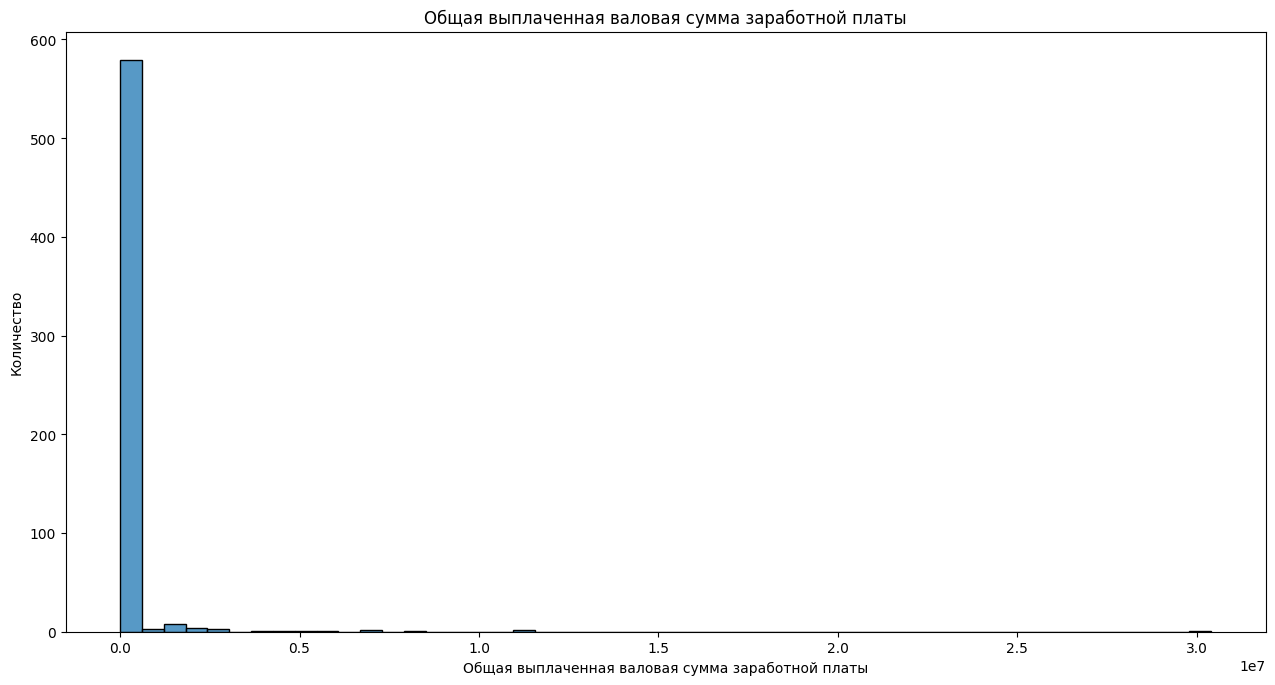

In [432]:
fig = plt.figure(figsize=(12, 6))
axes = fig.add_axes([0, 0, 1, 1])

sns.histplot(data=data['salary'], ax=axes)
axes.set(xlabel='Общая выплаченная валовая сумма заработной платы', ylabel='Количество')
axes.set_title('Общая выплаченная валовая сумма заработной платы')

plt.show()

In [433]:
data_agg = data['salary'].describe().round(2).to_frame()
data_agg.columns = ['Зарплаты']
data_agg

,Зарплаты
count,607.00
mean,324000.06
std,1544357.49
min,4000.00
25%,70000.00
50%,115000.00
75%,165000.00
max,30400000.00


In [434]:
# проводим тест Шапиро - Уилка
_, p = stats.shapiro(data['salary'])
print('p-value = %.2f' % (p))

if p <= alpha:
    print('Распределение валовых зарплат не нормальное')
else:
    print('Распределение валовых зарплат нормальное')

p-value = 0.00
Распределение валовых зарплат не нормальное


# Распределение валовых зарплат

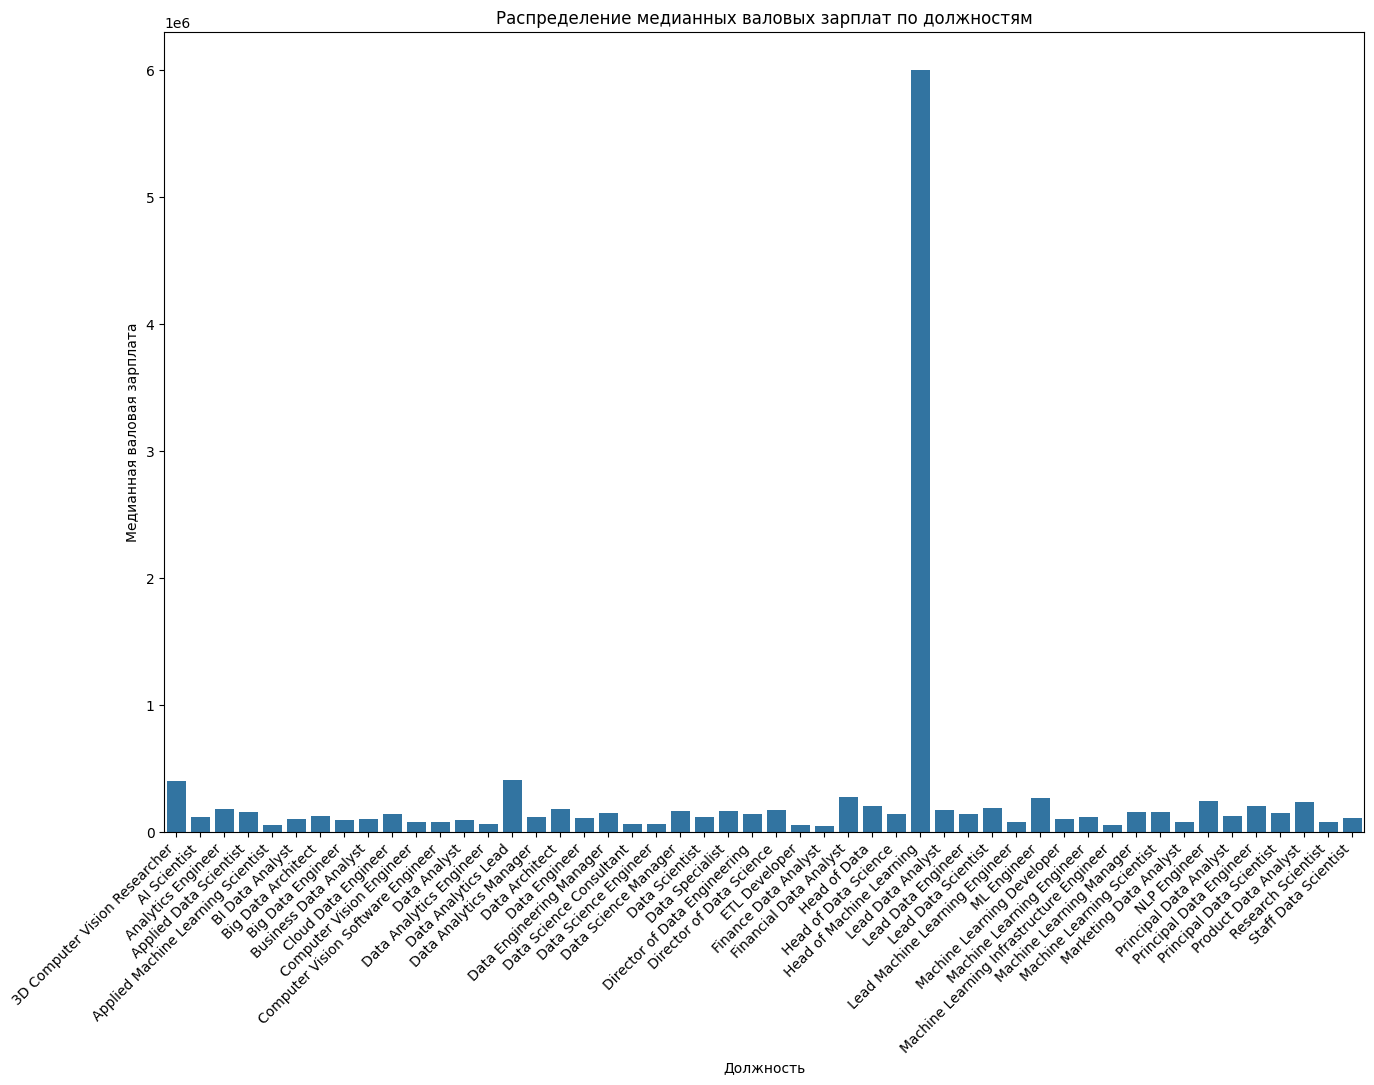

In [511]:
fig = plt.figure(figsize=(12, 8))
axes = fig.add_axes([0, 0, 1, 1])

vacancy_salary_agg = data.groupby(by='job_title', observed=True)['salary'].median()
vacancy_salary_agg

sns.barplot(x=vacancy_salary_agg.index, y=vacancy_salary_agg.values, ax=axes)
axes.tick_params(axis='x', labelrotation=45)
plt.setp(axes.get_xticklabels(), ha='right')
axes.set(xlabel='Должность', ylabel='Медианная валовая зарплата')
axes.set_title('Распределение медианных валовых зарплат по должностям')

plt.show()

In [436]:
data[data['job_title'] == 'Head of Machine Learning']['salary_currency'].value_counts()

salary_currency
INR    1
AUD    0
BRL    0
CHF    0
CAD    0
CNY    0
DKK    0
EUR    0
CLP    0
GBP    0
HUF    0
JPY    0
MXN    0
PLN    0
SGD    0
TRY    0
USD    0
Name: count, dtype: int64

# Статистический анализ данных

Можно заметить на графике, что валовая зарплата Head of Machine Learning явно выбивается из общей картины. Сформулируем гипотезы:  
H0: Медианная валовая зарплата должности Head of Machine Learning не отличается значимо от валовых зарплат других должностей (т.е. наблюдаемое различие случайно).  
H1: Медианная валовая зарплата должности Head of Machine Learning значимо выше, чем у остальных.

In [437]:
# проводим тест Шапиро - Уилка
_, p = stats.shapiro(vacancy_salary_agg.values)
print('p-value = %.2f' % (p))

if p <= alpha:
    print('Распределение валовых зарплат по должностям в usd не нормальное')
else:
    print('Распределение валовых зарплат по должностям в usd нормальное')

p-value = 0.00
Распределение валовых зарплат по должностям в usd не нормальное


In [438]:
alpha = 0.05

group1 = [vacancy_salary_agg['Head of Machine Learning']]
group2 = vacancy_salary_agg.drop('Head of Machine Learning').values

_, p = stats.mannwhitneyu(group1, group2)

print('p-value = %.3f' % (p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))
    

p-value = 0.096
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


# Распределение вакансий по годам

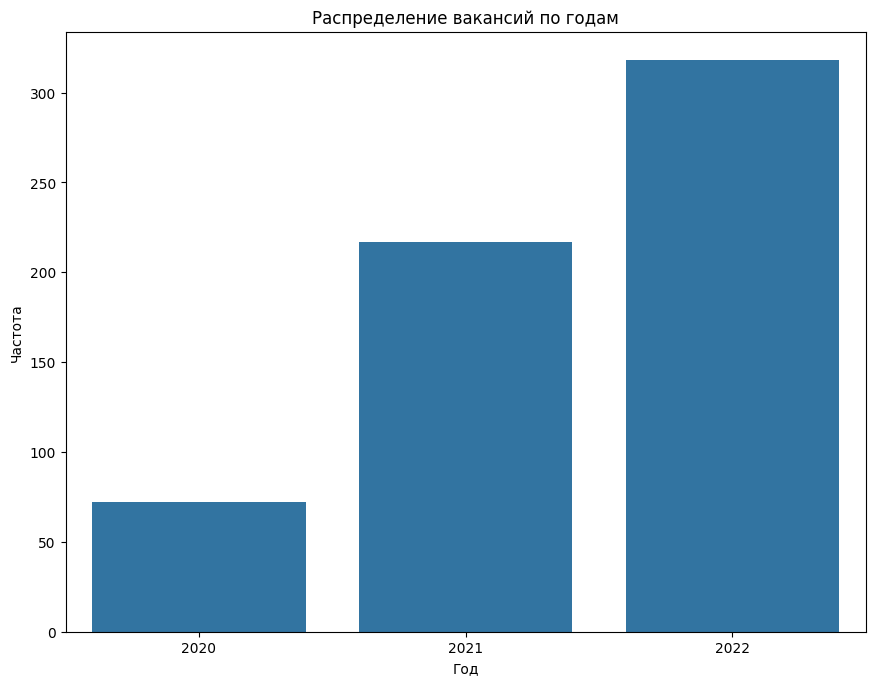

In [439]:
fig = plt.figure(figsize=(8, 6))
axes = fig.add_axes([0, 0, 1, 1])

sns.barplot(data['work_year'].value_counts(), ax=axes)
axes.set(xlabel='Год', ylabel='Частота')
axes.set_title('Распределение вакансий по годам')

plt.show()

In [440]:
year_stats = data['work_year'].value_counts().sort_index()
year_pct = data['work_year'].value_counts(normalize=True).round(2).sort_index() * 100
year_df = pd.DataFrame({
    'Количество': year_stats,
    'Доля, %': year_pct
})
print('Рапределение вакансий по годам')
display(year_df)
print(f'\nВсего вакансий: {len(data)}')
print(f'Количество уникальных лет: {data['work_year'].nunique()}')
print(f'Самый популярный год: {data['work_year'].mode()[0]}')

Рапределение вакансий по годам


,Количество,"Доля, %"
work_year,,
2020,72,12.0
2021,217,36.0
2022,318,52.0



Всего вакансий: 607
Количество уникальных лет: 3
Самый популярный год: 2022


# Статистический анализ данных
Проверим распределения на гомогенность. Отличается ли наблюдаемое распределение вакансий по годам от ожидаемого.  
H0: Вакансии распределены по годам равномерно.  
H1: Распределение вакансий зависит от года.  

In [441]:
observed = data['work_year'].value_counts().sort_index()
expected = [len(data) / len(observed)] * len(observed)

chi2, p = chisquare(f_obs=observed, f_exp=expected)

print('p-value = {}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 1.5148123870147166e-33
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


# Влияние различных годов на профессию Data Scientist

In [442]:
data_scientists = data[data['job_title'].str.contains('Data Scientist')]
data_scientists_stat = data_scientists['work_year'].value_counts(ascending=True)

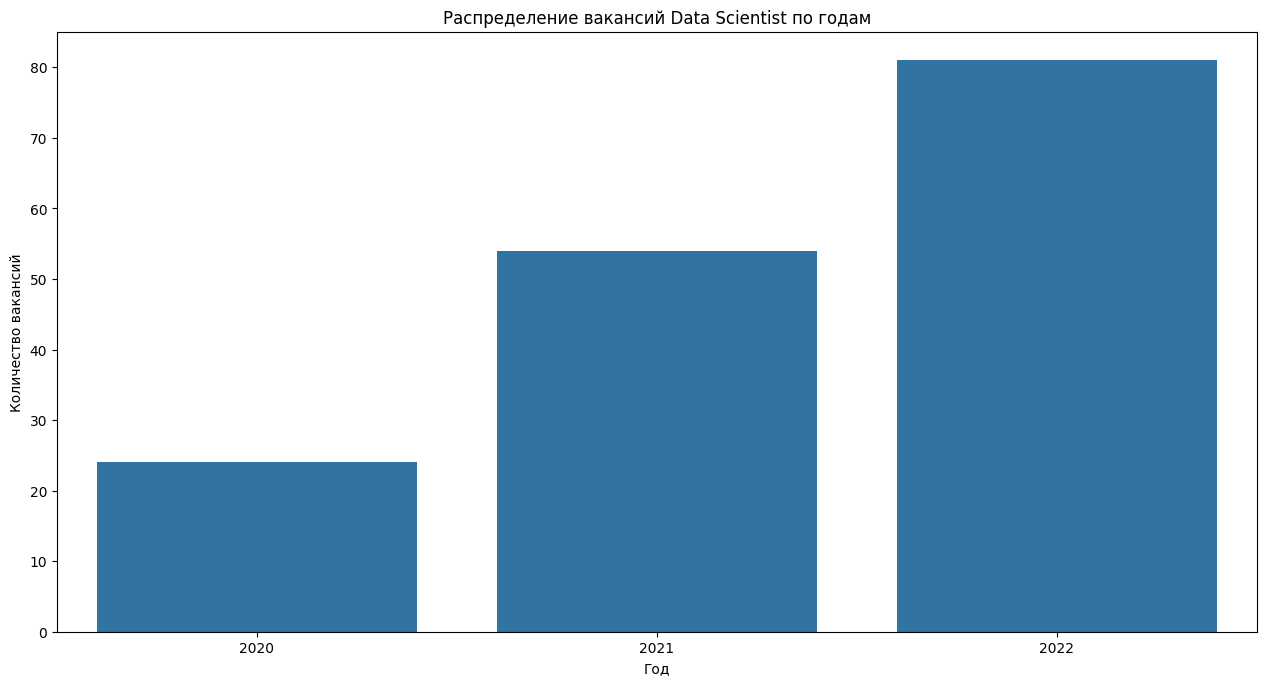

In [443]:
fig = plt.figure(figsize=(12, 6))
axes = fig.add_axes([0, 0, 1, 1])

sns.barplot(x=data_scientists_stat.index, y=data_scientists_stat.values, ax=axes)
axes.set(xlabel='Год', ylabel='Количество вакансий')
axes.set_title('Распределение вакансий Data Scientist по годам')

plt.show()

# Статистический анализ данных
Проверим распределения на гомогенность. Отличается ли наблюдаемое распределение вакансий по годам от ожидаемого.  
H0: Вакансии распределены по годам равномерно.  
H1: Распределение вакансий зависит от года.  

In [444]:
observed = data_scientists_stat.sort_index().values
expected = np.repeat(len(data_scientists) / len(observed), len(observed))

chi2, p = chisquare(f_obs=observed, f_exp=expected)

print('p-value = {}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 2.1781437199368478e-07
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


# Растёт ли профессия Data Scientist быстрее рынка?

In [445]:
all_jobs = data['work_year'].value_counts().sort_index()
ds_jobs = data_scientists['work_year'].value_counts().sort_index()

market_df = pd.DataFrame({
    "all": all_jobs,
    "ds": ds_jobs
})

market_df["non_ds"] = market_df["all"] - market_df["ds"]
market_df["ds_share_pct"] = ((market_df["ds"] / market_df["all"]) * 100).round(1)
market_df

,all,ds,non_ds,ds_share_pct
work_year,,,,
2020,72,24,48,33.3
2021,217,54,163,24.9
2022,318,81,237,25.5


Из анализа видно, что количество вакансий Data Scientist выросло, но доля в рынке снизилась.  
Проверим это статистически.  
H0: Доля Data Scientist вакансий не зависит от года  
H1: Доля Data Scientist вакансий зависит от года  

In [446]:
table = market_df[["ds", "non_ds"]].values

chi2, dof, p, expected = chi2_contingency(table)

print("p-value = {:.2f}".format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 2.00
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


# Распределение медианных зарплат Data Scientist в usd по годам

In [447]:
data_science_agg = data_scientists.groupby(by='work_year')['salary_in_usd'].median()
data_science_agg

work_year
2020     72693.0
2021     78842.0
2022    140000.0
Name: salary_in_usd, dtype: float64

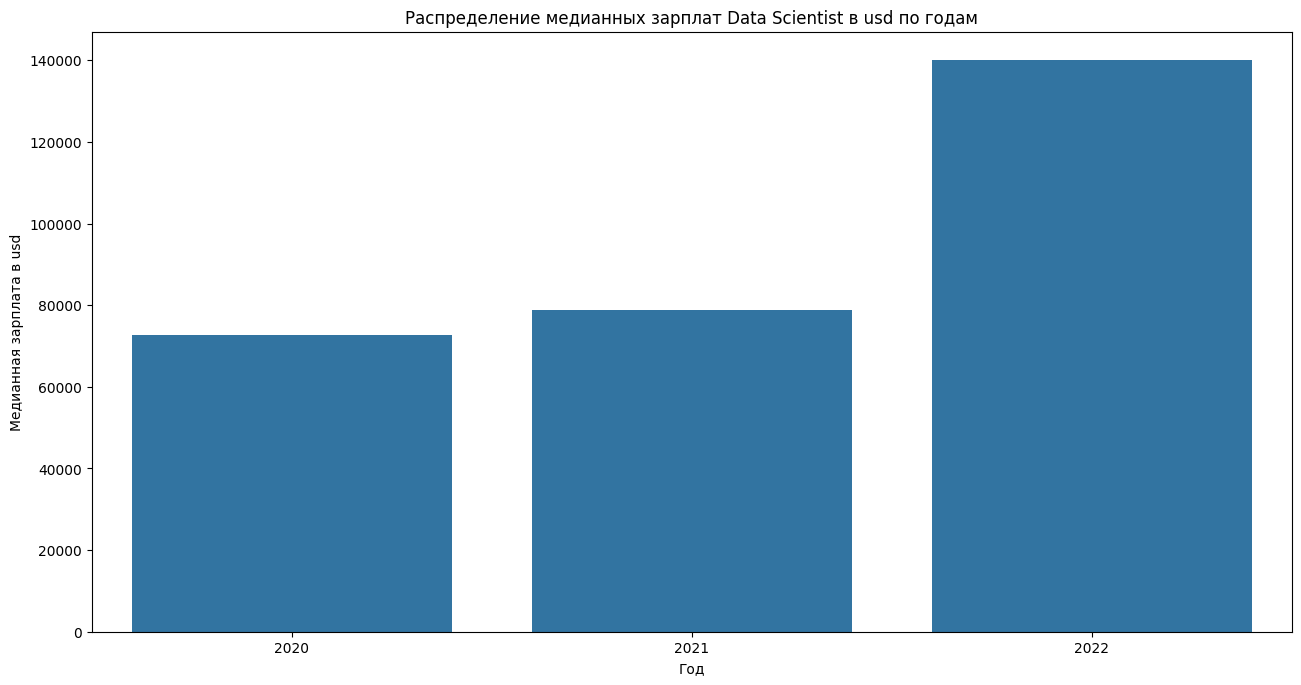

In [448]:
fig = plt.figure(figsize=(12, 6))
axes = fig.add_axes([0, 0, 1, 1])

sns.barplot(x=data_science_agg.index, y=data_science_agg.values, ax=axes)
axes.set(xlabel='Год', ylabel='Медианная зарплата в usd')
axes.set_title('Распределение медианных зарплат Data Scientist в usd по годам')

plt.show()

# Статистический анализ
Проверим распределения на гомогенность. Отличается ли наблюдаемое распределение медианных зарплат Data Scientists по годам от ожидаемого.  
H0: Распределения зарплат одинаковы  
H1: Хотя бы одно распределение отличается  

In [449]:
year2020 = data_scientists[data_scientists['work_year'] == 2020]['salary']
year2021 = data_scientists[data_scientists['work_year'] == 2021]['salary']
year2022 = data_scientists[data_scientists['work_year'] == 2022]['salary']

stat, p = stats.kruskal(year2020, year2021, year2022)

print('p-value = {}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.0015038915251531315
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


# Распределение уровней опыта

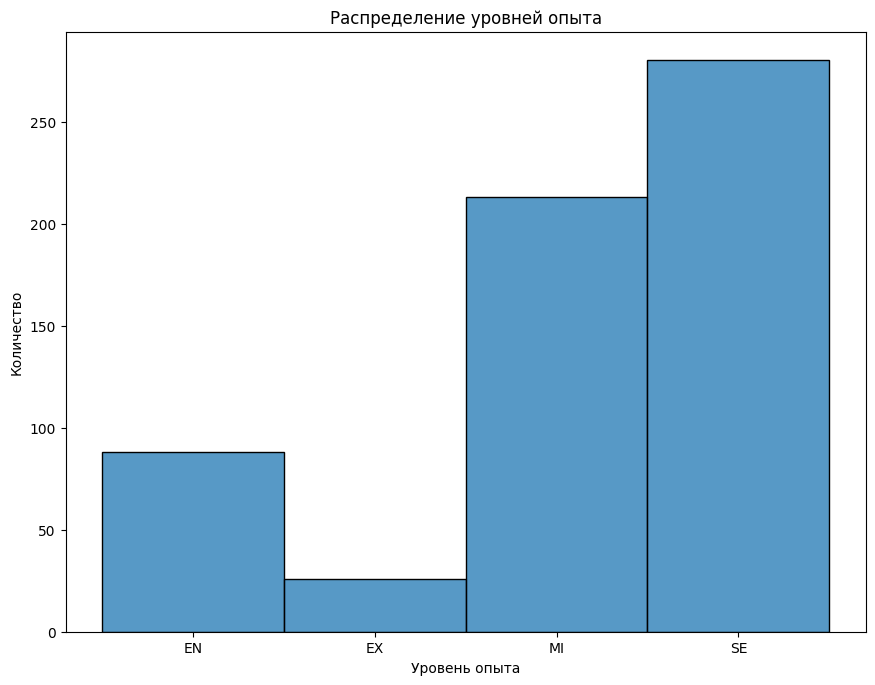

In [450]:
fig = plt.figure(figsize=(8, 6))
axes = fig.add_axes([0, 0, 1, 1])

sns.histplot(data['experience_level'], ax=axes)
axes.set(xlabel='Уровень опыта', ylabel='Количество')
axes.set_title('Распределение уровней опыта')

plt.show()

In [451]:
exp_stats = data['experience_level'].value_counts()
exp_pct = data['experience_level'].value_counts(normalize=True).round(2) * 100
exp_df = pd.DataFrame({
    'Количество': exp_stats,
    'Доля, %': exp_pct
}).sort_values(by='Количество')
display(exp_df)

,Количество,"Доля, %"
experience_level,,
EX,26,4.0
EN,88,14.0
MI,213,35.0
SE,280,46.0


# Статистический анализ
H0: Распределение уровней опыта не зависит от года (спрос на грейды не меняется)  
H1: Распределение уровней опыта зависит от года (то есть какие-то грейды растут быстрее)  

In [452]:
ct = pd.crosstab(data['work_year'], data['experience_level'])

chi2, p, dof, expected = chi2_contingency(ct)

print('p-value = {:.2f}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.00
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Статистический анализ показал, что распределение уровней опыта зависит от года, когда опубликована вакансия.   
Для определения грейда, рост которого наиболее сильно выражен были расчитанны стандартизированные остатки Пирсона.  
Значения остатка больше 2 свидетельствуют о значимом отклонении наблюдаемой частоты от ожидаемой.  

In [453]:
residuals = (ct - expected) / np.sqrt(expected)

top_residuals = residuals.stack().sort_values(ascending=False).head(1)
print(top_residuals)

work_year  experience_level
2022       SE                  3.823749
dtype: float64


Максимальное значение (3.82) наблюдается для уровня Senior в 2022 году, что указывает на статистически значимый рост доли вакансий для данного уровня по сравнению с ожидаемым распределением.  
Таким образом, уровень Senior демонстрирует наиболее выраженный уровень спроса.  

# Распределение зарплат Data Scientists в usd по уровням опыта

# Статистический анализ
Проверим есть ли различие по распределениям заплат в уровнях опыта Data Scientists.  
H0: Распределения зарплат одинаковы во всех группах.  
H1: Расеределения зарплат различаются хотя бы для одного уровня опыта.  

In [454]:
groups = [
    data_scientists[data_scientists['experience_level'] == 'EN']['salary_in_usd'],
    data_scientists[data_scientists['experience_level'] == 'MI']['salary_in_usd'],
    data_scientists[data_scientists['experience_level'] == 'SE']['salary_in_usd'],
    data_scientists[data_scientists['experience_level'] == 'EX']['salary_in_usd']
]

stat, p = kruskal(*groups)

print('p-value = {:.3f}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Теперь визуализируем распределения, что бы посмотреть какие группы отличаются.

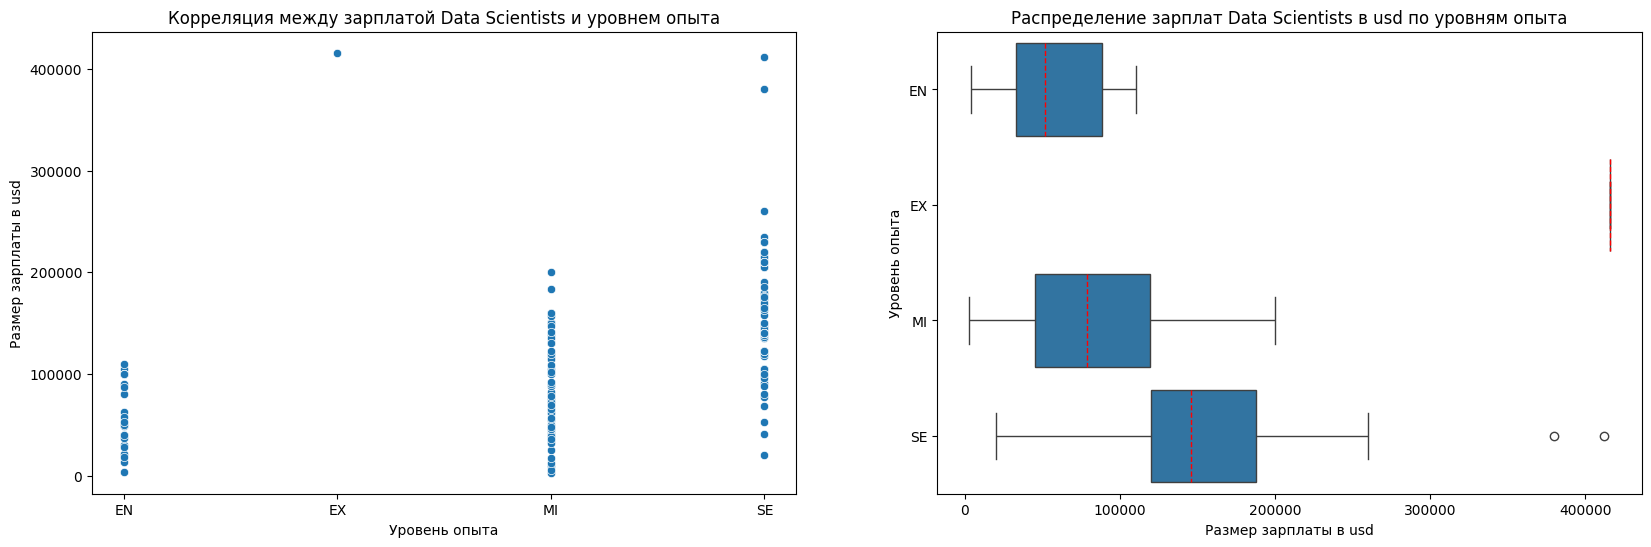

In [455]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.scatterplot(x='experience_level', y='salary_in_usd', data=data_scientists, ax=axes[0])
axes[0].set_title('Корреляция между зарплатой Data Scientists и уровнем опыта')
axes[0].set(xlabel='Уровень опыта', ylabel='Размер зарплаты в usd')

sns.boxplot(y='experience_level', x='salary_in_usd', data=data_scientists, ax=axes[1], orient='h', medianprops={'color': 'red', 'linestyle': '--'})
axes[1].set_title('Распределение зарплат Data Scientists в usd по уровням опыта')
axes[1].set(ylabel='Уровень опыта', xlabel='Размер зарплаты в usd')

plt.show()

# Распределение типа трудоустройтсва

In [456]:
# fig = plt.figure(figsize=(10, 6))
# axes = fig.add_axes([0, 0, 1, 1])

# sns.histplot(data['employment_type'], ax=axes)
# axes.set(xlabel='Тип трудоустройства', ylabel='Количество')
# axes.set_title('Распределение типа трудоустройства')

# Не информативный признак, так как 99.8% вакансий имеют тип трудоустройства 'FT'

plt.show()

# Распределение должностей соискателей

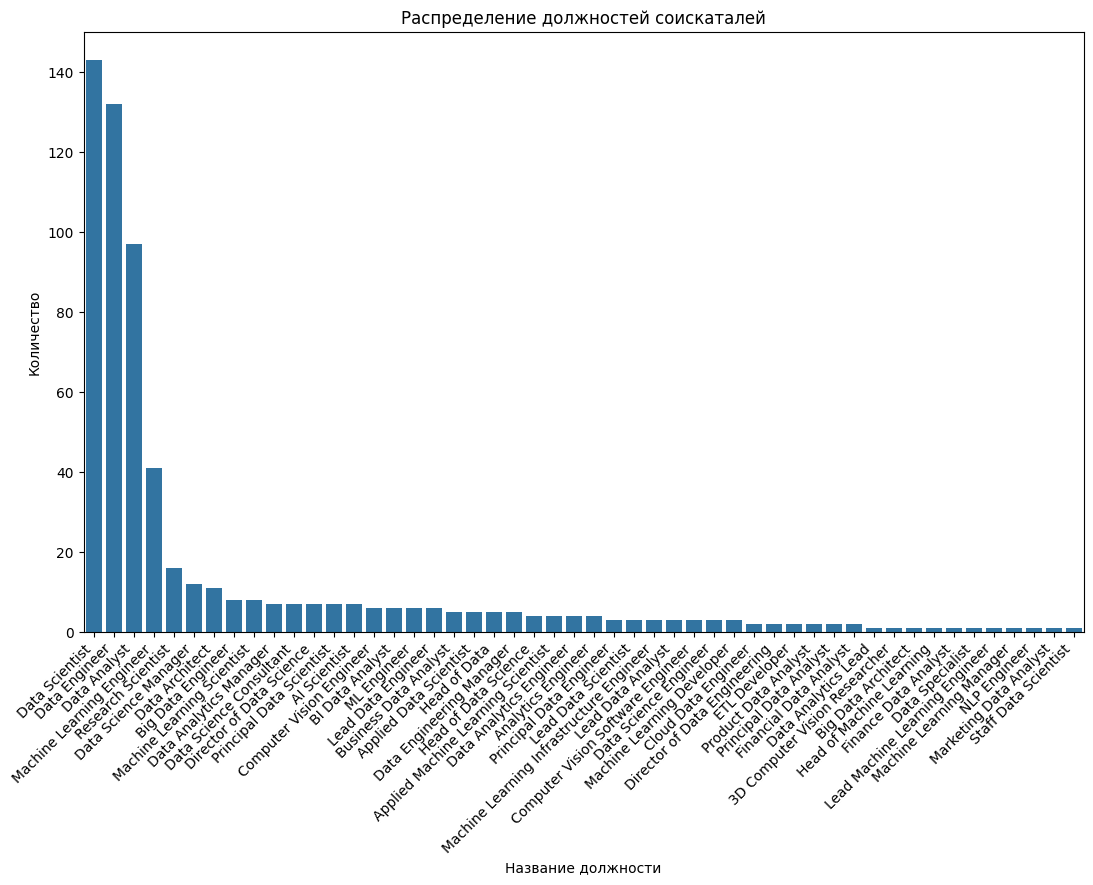

In [510]:
fig = plt.figure(figsize=(10, 6))
axes = fig.add_axes([0, 0, 1, 1])

job_title_counts = data['job_title'].value_counts().sort_values(ascending=False)

sns.barplot(x=job_title_counts.index, y=job_title_counts.values, ax=axes, order=job_title_counts.index)
axes.tick_params(axis='x', labelrotation=45)
plt.setp(axes.get_xticklabels(), ha='right')
axes.set_title('Распределение должностей соискаталей')
axes.set_xlabel('Название должности')
axes.set_ylabel('Количество')

plt.show()

In [458]:
job_title_stat = data['job_title'].value_counts(ascending=False).to_frame()
print(f'Всего уникальных должностей: {job_title_stat.shape[0]}')
print(f'Самая популярная должность: {job_title_stat.index[0]}')
display(job_title_stat)

Всего уникальных должностей: 50
Самая популярная должность: Data Scientist


,count
job_title,
Data Scientist,143
Data Engineer,132
Data Analyst,97
Machine Learning Engineer,41
Research Scientist,16
Data Science Manager,12
Data Architect,11
Big Data Engineer,8
Machine Learning Scientist,8


# Статистический анализ
Проверим, равномерно ли распределены должности.  
H0: Должности распределены согласно ожидаемому распределению (равномерно).  
H1: Распределение отличается.  

In [459]:
alpha = 0.05

counts = data['job_title'].value_counts()

p = chisquare(counts).pvalue

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Проверим гипотезу, зависит ли должность от уровня опыта.  
H0: Должность не связана с опытом.  
H1: Должность зависит от опыта.  

In [460]:
ct = pd.crosstab(data['experience_level'], data['job_title'])
chi2, p, dof, expected = chi2_contingency(ct)

print('p-value = {:.2f}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.00
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Посчитаем остатки Пирсона, что бы лучше понять связь должности с опытом.

In [461]:
expected = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

pearson_residuals = (ct - expected) / np.sqrt(expected)
residuals_long = pearson_residuals.stack().reset_index()
residuals_long.columns = ['experience_level', 'job_title', 'pearson_residual']
residuals_long.sort_values(by='pearson_residual', ascending=False).head(10)

,experience_level,job_title,pearson_residual
75,EX,Director of Data Science,10.409888
80,EX,Head of Data Science,6.833753
81,EX,Head of Machine Learning,4.624823
52,EX,Analytics Engineer,4.417860
19,EN,Data Science Consultant,3.955953
79,EX,Head of Data,3.858898
1,EN,AI Scientist,2.963285
95,EX,Principal Data Engineer,2.431163
11,EN,Computer Vision Software Engineer,2.373162
10,EN,Computer Vision Engineer,2.283953


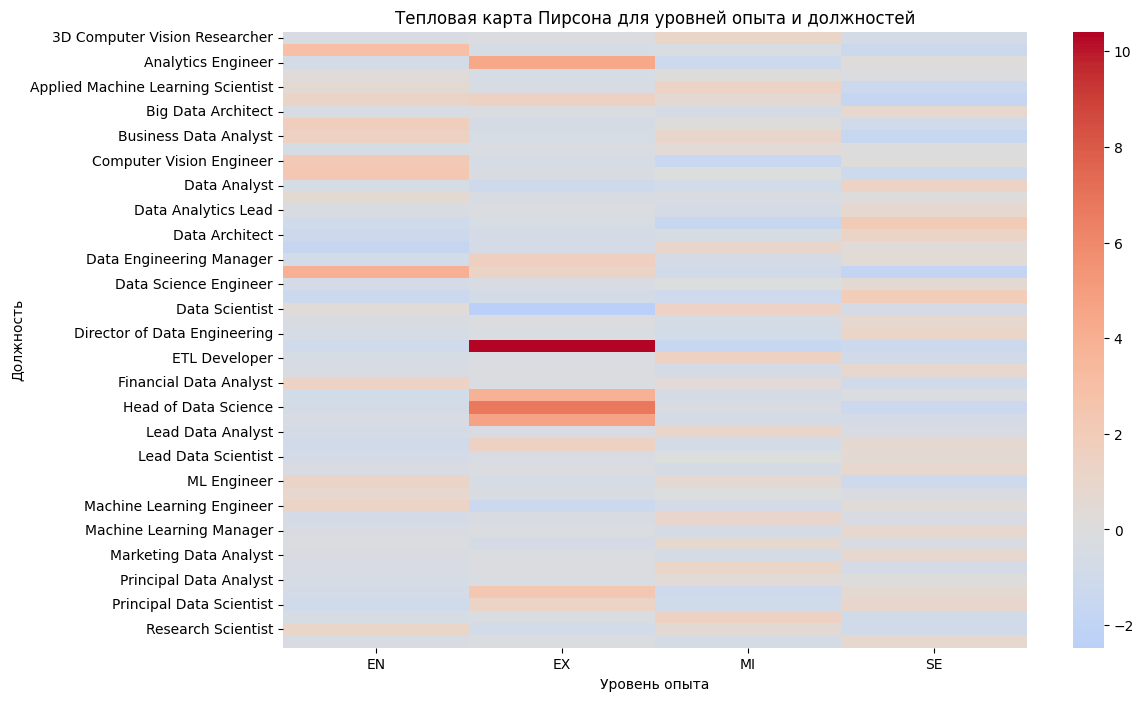

In [462]:
plt.figure(figsize=(12, 8))

pearson_residuals = pearson_residuals.transpose()

sns.heatmap(pearson_residuals, cmap='coolwarm', center=0)

plt.title('Тепловая карта Пирсона для уровней опыта и должностей')
plt.xlabel('Уровень опыта')
plt.ylabel('Должность')
plt.show()

Остатки Пирсона и визуализация показывают, что на должность инженера чаще требуются опытные соискатели (уровнея Senior и Expert), менне опытные соискатели (уровень Junior) чаще требуются на должность аналитика данных.

# Распределение стран проживания сотрудников

# Статистический анализ
Проверим, равномерно ли распределены страны проживания сотрудников.  
H0: Страны распределены согласно ожидаемому распределению (равномерно).  
H1: Распределение отличается.  

In [463]:
alpha = 0.05

counts = data['employee_residence'].value_counts()

p = chisquare(counts).pvalue

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


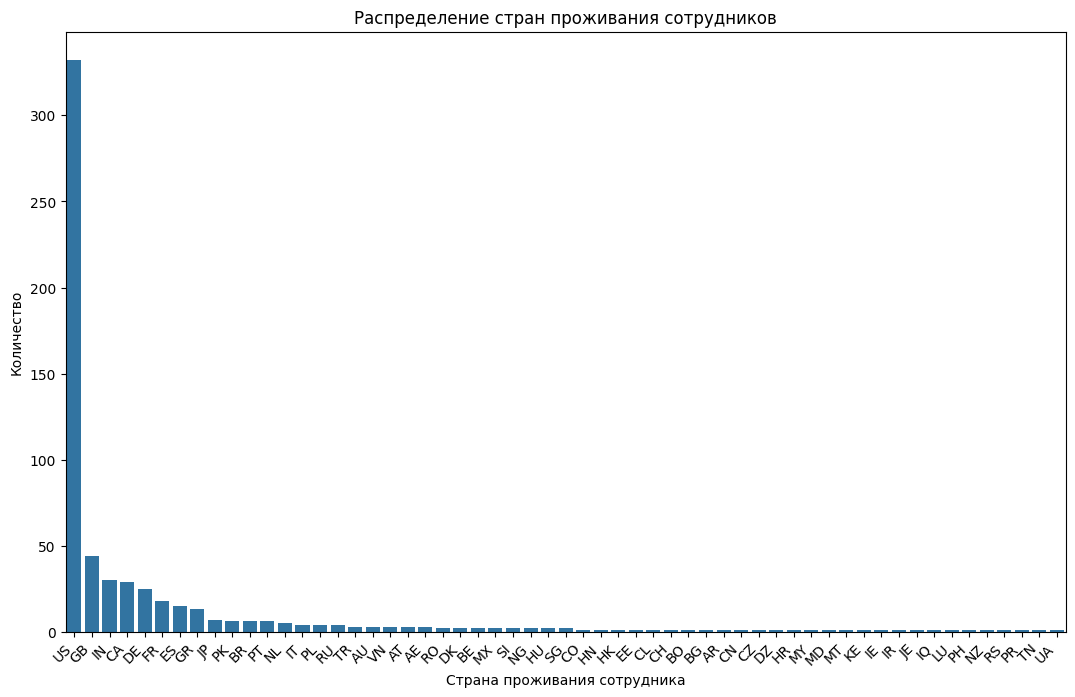

In [464]:
fig = plt.figure(figsize=(10, 6))
axes = fig.add_axes([0, 0, 1, 1])

employee_residence_counts = data['employee_residence'].value_counts().sort_values(ascending=False)

# построим столбчатую диаграмму напрямую — так избегаем возможных проблем с передачей Series в seaborn
sns.barplot(x=employee_residence_counts.index, y=employee_residence_counts.values, ax=axes, order=employee_residence_counts.index)
axes.set_xticks(range(len(employee_residence_counts)))
axes.set_xticklabels(employee_residence_counts.index, rotation=45, ha='right')
axes.set(xlabel='Страна проживания сотрудника', ylabel='Количество')
axes.set_title('Распределение стран проживания сотрудников')

plt.show()

In [465]:
print(f'Всего уникальных стран проживания сотрудников: {employee_residence_counts.shape[0]}')
print(f'Самая популярная страна проживания сотрудников: {employee_residence_counts.index[0]}')
display(employee_residence_counts)

Всего уникальных стран проживания сотрудников: 57
Самая популярная страна проживания сотрудников: US


employee_residence
US    332
GB     44
IN     30
CA     29
DE     25
FR     18
ES     15
GR     13
JP      7
PK      6
BR      6
PT      6
NL      5
IT      4
PL      4
RU      4
TR      3
AU      3
VN      3
AT      3
AE      3
RO      2
DK      2
BE      2
MX      2
SI      2
NG      2
HU      2
SG      2
CO      1
HN      1
HK      1
EE      1
CL      1
CH      1
BO      1
BG      1
AR      1
CN      1
CZ      1
DZ      1
HR      1
MY      1
MD      1
MT      1
KE      1
IE      1
IR      1
JE      1
IQ      1
LU      1
PH      1
NZ      1
RS      1
PR      1
TN      1
UA      1
Name: count, dtype: int64

# Влияние стран проживания Data Scientists на зарплату

# Статистический анализ
Проверим гипотезу, влияет ли проживание специалистов по Data Science на уровень зарплаты.  
H0: Страна не влияет на уровень зарплаты (все страны имеют примерно одинаковый уровень дохода).  
H1: Зарплата в разных странах отличается значительно.  
Примечание к тесту: Страны с числом наблюдений менее 10 были исключены из анализа, так как малые выборки могут приводить к искажениям p-value и нестабильности рангов в тесте Краскела-Уоллиса.

In [466]:
alpha = 0.05

data_scientists_country = data_scientists['employee_residence'].value_counts().sort_values(ascending=False)
# Отбрасываем страны с количеством вакансий меньше 10, чтобы избежать проблем с малой выборкой в тесте
data_scientists_country = data_scientists_country[data_scientists_country >= 10]
data_scientists_countries = data_scientists_country.index.tolist()
data_scientists_country_groups = [data_scientists[data_scientists['employee_residence'] == country]['salary_in_usd'] for country in data_scientists_countries]

stat, p = kruskal(*data_scientists_country_groups)

print('p-value = {:.3f}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Построим визуализацию, что бы наглядно посмотреть на разницу доходов в разных странах.

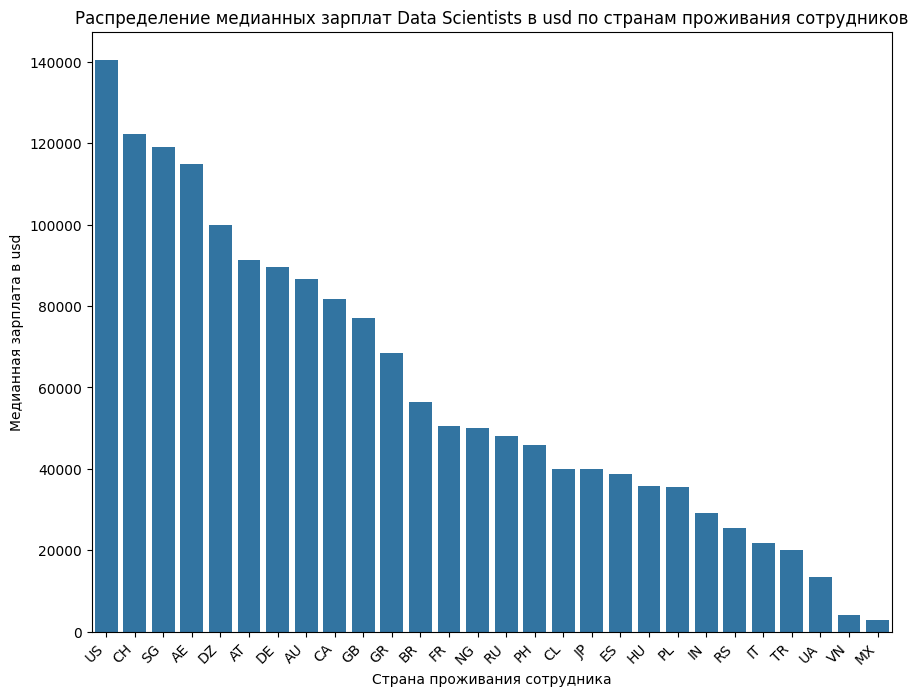

In [509]:
fig = plt.figure(figsize=(8, 6))
axes = fig.add_axes([0, 0, 1, 1])

data_scientists_country = data_scientists.groupby('employee_residence', observed=True)['salary_in_usd'].median().sort_values(ascending=False)
data_scientists_country = data_scientists_country[data_scientists_country > 0]

sns.barplot(x=data_scientists_country.index, y=data_scientists_country.values, ax=axes, order=data_scientists_country.index)
axes.tick_params(axis='x', labelrotation=45)
plt.setp(axes.get_xticklabels(), ha='right')
axes.set(xlabel='Страна проживания сотрудника', ylabel='Медианная зарплата в usd')
axes.set_title('Распределение медианных зарплат Data Scientists в usd по странам проживания сотрудников')

plt.show()

Так же проверим зависит ли страна от уровня опыта.  
H0: Уровень опыта и страна не связаны.  
H1: Уровень опыта и страна связаны (страна зависит от опыта).  

In [468]:
alpha = 0.05

ct = pd.crosstab(data['employee_residence'], data['experience_level'])
chi2, p, dof, expected = chi2_contingency(ct)

print('p-value = {:.2f}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.00
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Посмотрим более внимательно где проживают наиболее опытные разработчики.

In [469]:
expected = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
pearson_residuals = (ct - expected) / np.sqrt(expected)
residuals_long = pearson_residuals.stack().reset_index()
residuals_long.columns = ['employee_residence', 'experience_level', 'pearson_residual']
residuals_long.sort_values(by='pearson_residual', ascending=False).head(10)

,employee_residence,experience_level,pearson_residual
223,US,SE,4.674929
197,RU,EX,4.417860
82,GB,MI,3.705472
172,PK,EN,3.356157
108,IN,EN,3.189058
60,DK,EN,3.175753
74,ES,MI,2.936211
86,GR,MI,2.546184
12,AU,EN,2.373162
56,DE,EN,2.298383


Как видно, наиболее опытные разработчики (Senior и Expert) проживают В США и России. Причём экспертов больше всего в России, а сеньоров в США.

# Распределение удалённого объёма работы

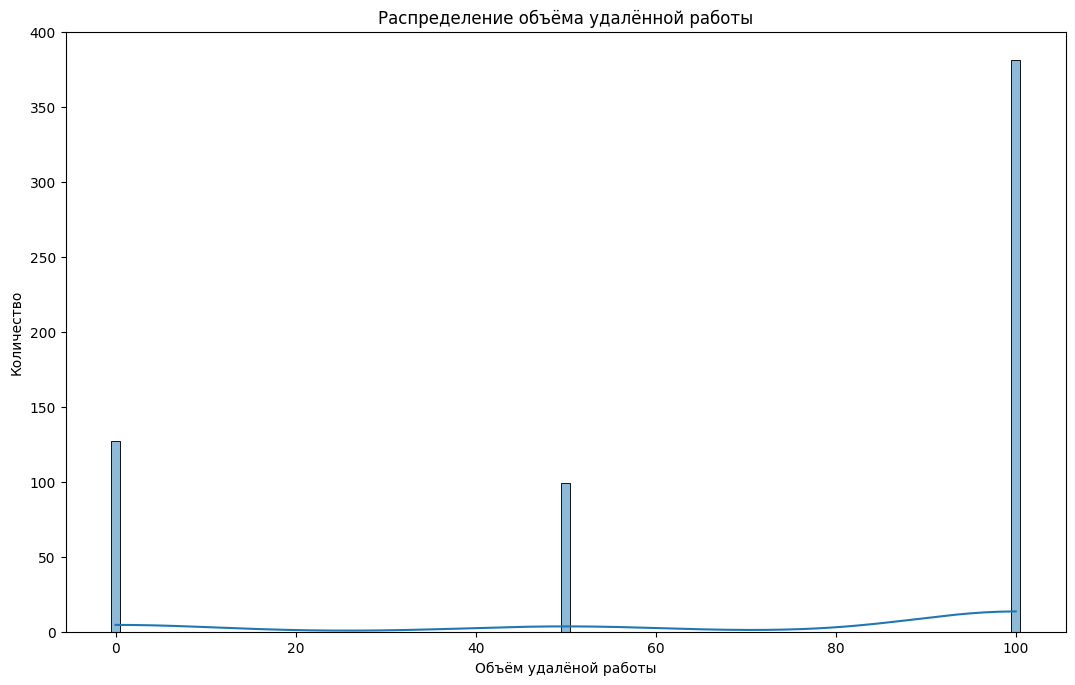

In [470]:
fig = plt.figure(figsize=(10, 6))
axes = fig.add_axes([0, 0, 1, 1])

sns.histplot(data=data['remote_ratio'], kde=True, ax=axes)
axes.set(xlabel='Объём удалёной работы', ylabel='Количество')
axes.set_title('Распределение объёма удалённой работы')

plt.show()

# Статистический анализ
Проверим связь объёма удалённой работы Data Scientist и опыта.  
H0: Объём удалённой работы Data Scientist не зависит от опыта (связи между ними нет).  
H1: Объём удалённой работы Data Scientist зависит от опыта (связь есть).  

In [471]:
alpha = 0.05

ct = pd.crosstab(data_scientists['remote_ratio'], data_scientists['experience_level'])

chi2, p, dof, expected = chi2_contingency(ct)

print('p-value = {:.2f}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.03
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


In [472]:
expected = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
pearson_residuals = (ct - expected) / np.sqrt(expected)
residuals_long = pearson_residuals.stack().reset_index()
residuals_long.columns = ['remote_ratio', 'experience_level', 'pearson_residual']
residuals_long.sort_values(by='pearson_residual', ascending=False).head(10)

,remote_ratio,experience_level,pearson_residual
4,50,EN,2.071747
11,100,SE,1.389918
6,50,MI,0.950077
9,100,EX,0.576805
2,0,MI,0.509367
0,0,EN,-0.030619
3,0,SE,-0.405184
5,50,EX,-0.412082
1,0,EX,-0.513956
10,100,MI,-0.868343


Анализ остатков Пирсона показал, что Джуны статистически чаще работают в гибридном формате (50% удалённой работы). Для других уровней опыта значимых отклонений от ожидаемого распределения не обнаружено.

Объяснить найм джунов на гибридный формат можно объяснить тем, что компании хотят лучше контролировать начинающих специалистов.

# Зависимость зарплат в usd от объёма удалённой работы

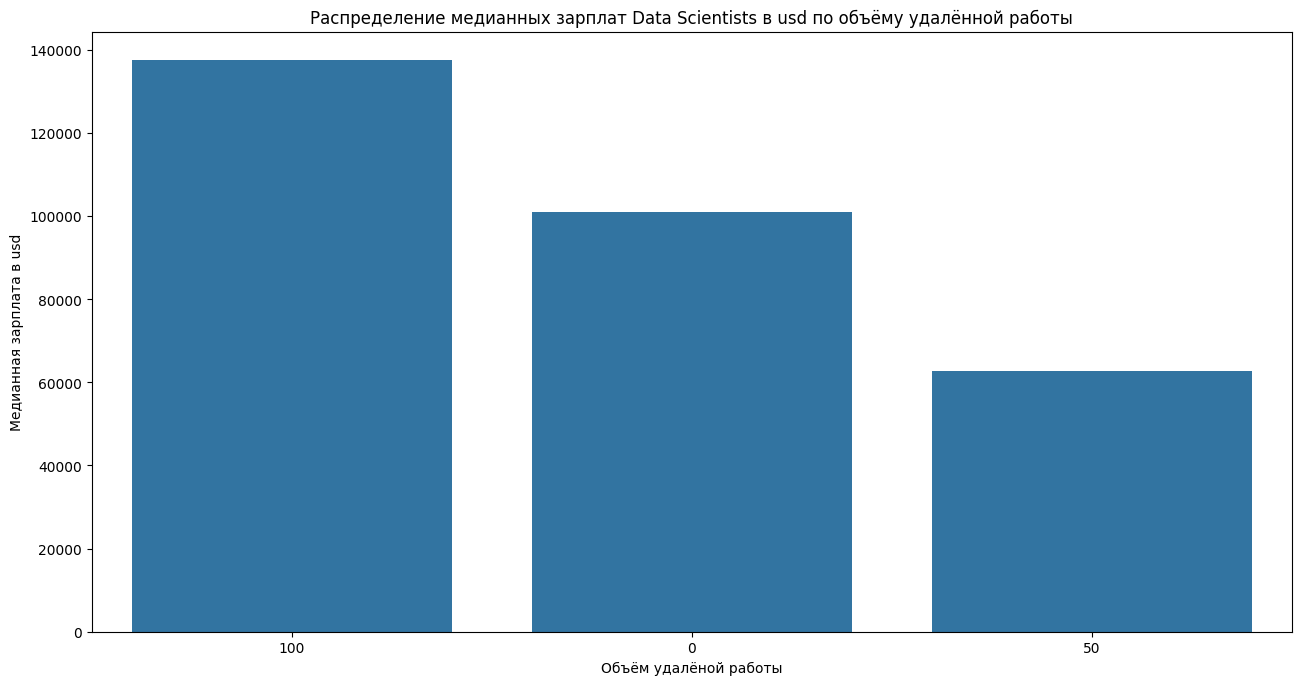

In [508]:
fig = plt.figure(figsize=(12, 6))
axes = fig.add_axes([0, 0, 1, 1])

data_scientists_remote = data_scientists.groupby('remote_ratio', observed=True)['salary_in_usd'].median().sort_values(ascending=False)
data_scientists_remote = data_scientists_remote[data_scientists_remote > 0]

sns.barplot(x=data_scientists_remote.index, y=data_scientists_remote.values, ax=axes, order=data_scientists_remote.index)
axes.set(xlabel='Объём удалёной работы', ylabel='Медианная зарплата в usd')
axes.set_title('Распределение медианных зарплат Data Scientists в usd по объёму удалённой работы')

plt.show()

# Статистический тест
Проверим гипотезу о связи объёма удалённой работы Data Scientist и заработной платы.  
H0: Зарплата Data Scientist не зависит от объёма удалённой работы.  
H1: Зарплата Data Scientist зависит от объёма удалённой работы.

In [474]:
alpha = 0.05

data_scientists_remote_groups = [data_scientists[data_scientists['remote_ratio'] == ratio]['salary_in_usd'] for ratio in data_scientists['remote_ratio'].unique()]
stat, p = kruskal(*data_scientists_remote_groups)

print('p-value = {:.3f}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Посмотрим более детально зарплаты на различных объёмах удалённой работы.

In [507]:
data_scientists.groupby('remote_ratio', observed=True)['salary_in_usd'].median().sort_values(ascending=False)

remote_ratio
100    137485.0
0      101050.0
50      62726.0
Name: salary_in_usd, dtype: float64

Отсюда видим, что наибольшие зарплаты у нас на удалёнке. В то время как гибридный формат работы на последнем месте по зп. Видимо это связано с тем, что на гибриде чаще работают специалисты начального уровня.

# Распределение стран главного офиса работодателей или филиалов

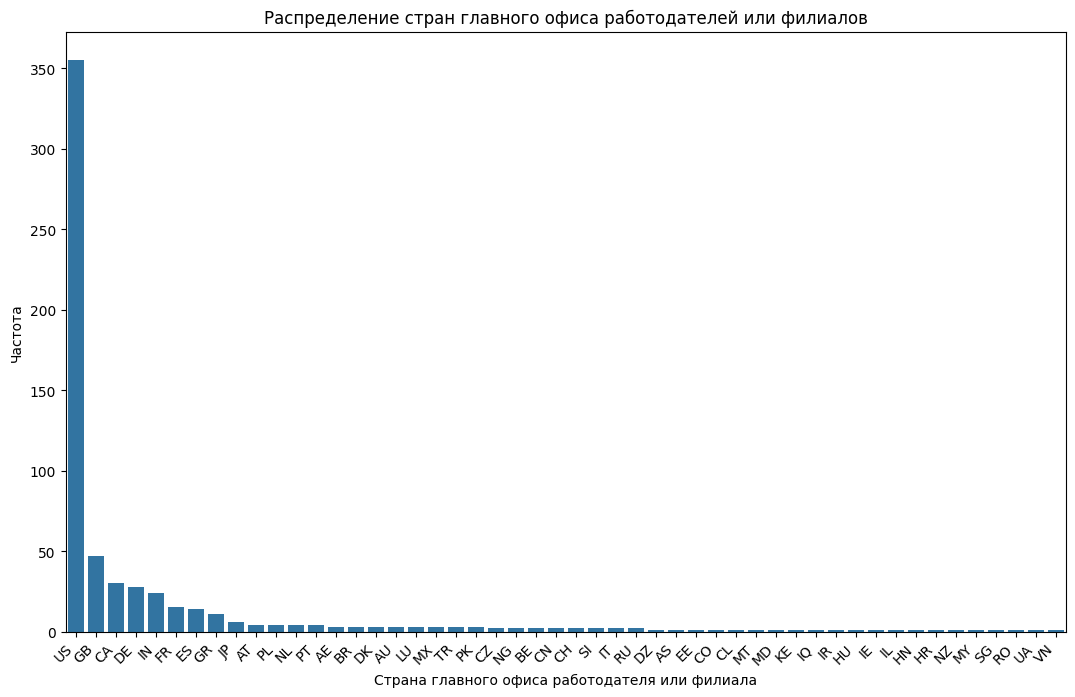

In [506]:
fig = plt.figure(figsize=(10, 6))
axes = fig.add_axes([0, 0, 1, 1])

company_location_counts = data['company_location'].value_counts().sort_values(ascending=False)

sns.barplot(company_location_counts, ax=axes, order=company_location_counts.index)
axes.tick_params(axis='x', labelrotation=45)
plt.setp(axes.get_xticklabels(), ha='right')
axes.set(xlabel='Страна главного офиса работодателя или филиала', ylabel='Частота')
axes.set_title('Распределение стран главного офиса работодателей или филиалов')

plt.show()

In [477]:
print(f'Всего стран главного офиса работодателей или филиала: {company_location_counts.shape[0]}')
print(f'Самая популярная страна главного офиса работодателя или филиала: {company_location_counts.index[0]}')
display(company_location_counts)

Всего стран главного офиса работодателей или филиала: 50
Самая популярная страна главного офиса работодателя или филиала: US


company_location
US    355
GB     47
CA     30
DE     28
IN     24
FR     15
ES     14
GR     11
JP      6
AT      4
PL      4
NL      4
PT      4
AE      3
BR      3
DK      3
AU      3
LU      3
MX      3
TR      3
PK      3
CZ      2
NG      2
BE      2
CN      2
CH      2
SI      2
IT      2
RU      2
DZ      1
AS      1
EE      1
CO      1
CL      1
MT      1
MD      1
KE      1
IQ      1
IR      1
HU      1
IE      1
IL      1
HN      1
HR      1
NZ      1
MY      1
SG      1
RO      1
UA      1
VN      1
Name: count, dtype: int64

# Статистический анализ
Проверим гипотезу зависимости страны компании и её размера.  
H0: Между страной компании и её размером нет связи.  
H1: Между страной компании и её размером есть связь.  

In [478]:
alpha = 0.05

country_counts = data['company_location'].value_counts()
valid_countries = country_counts[country_counts >= 5].index
filtered_data = data[data['company_location'].isin(valid_countries)].copy()
filtered_data['company_location'] = filtered_data['company_location'].cat.remove_unused_categories()

ct = pd.crosstab(filtered_data['company_location'], filtered_data['company_size'])
chi2, p, dof, expected = chi2_contingency(ct)

print('p-value = {:.2f}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.00
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


In [479]:
expected = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
pearson_residuals = (ct - expected) / np.sqrt(expected)
residuals_long = pearson_residuals.stack().reset_index()
residuals_long.columns = ['company_location', 'company_size', 'pearson_residual']
# Оставляем только те сочетания, которые вносят наибольший вклад в общую статистику
residuals_long = residuals_long[abs(residuals_long['pearson_residual']) > 2]
residuals_long.sort_values(by='pearson_residual', ascending=False).head(5)

,company_location,company_size,pearson_residual
23,JP,S,6.323939
18,IN,L,2.068175
5,DE,S,2.057948


Анализ остатков Пирсона показал, что в некоторых странах (JP, DE) небольшие компании (S) представлены статистически чаще ожидаемого, в то время как стране IN преобладают большие компании (L).

# Зависимость зарплат Data Scientists в usd от стран главного офиса работодателей или филиалов

# Статистический тест
Проверим есть ли статистические различия в зарплатах в зависимости от главного офиса работодателя.  
H0: Распределения зарплат для Data Scientist одинаковы для всех стран расположения головного офиса компании.   
H1: Хотя бы в одной стране распределение зарплат отличается.  

In [480]:
alpha = 0.05

company_locations_df = data_scientists['company_location'].value_counts().to_frame()
# Отбрасываем страны с количеством вакансий меньше 5, чтобы избежать проблем с малой выборкой в тесте
company_locations = company_locations_df[company_locations_df['count'] >= 5].copy().index.to_list()

company_locations_groups = [data_scientists[data_scientists['company_location'] == location]['salary_in_usd'] for location in company_locations]
stat, p = kruskal(*company_locations_groups)

print('p-value = {:.3f}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Построим визуализацию.

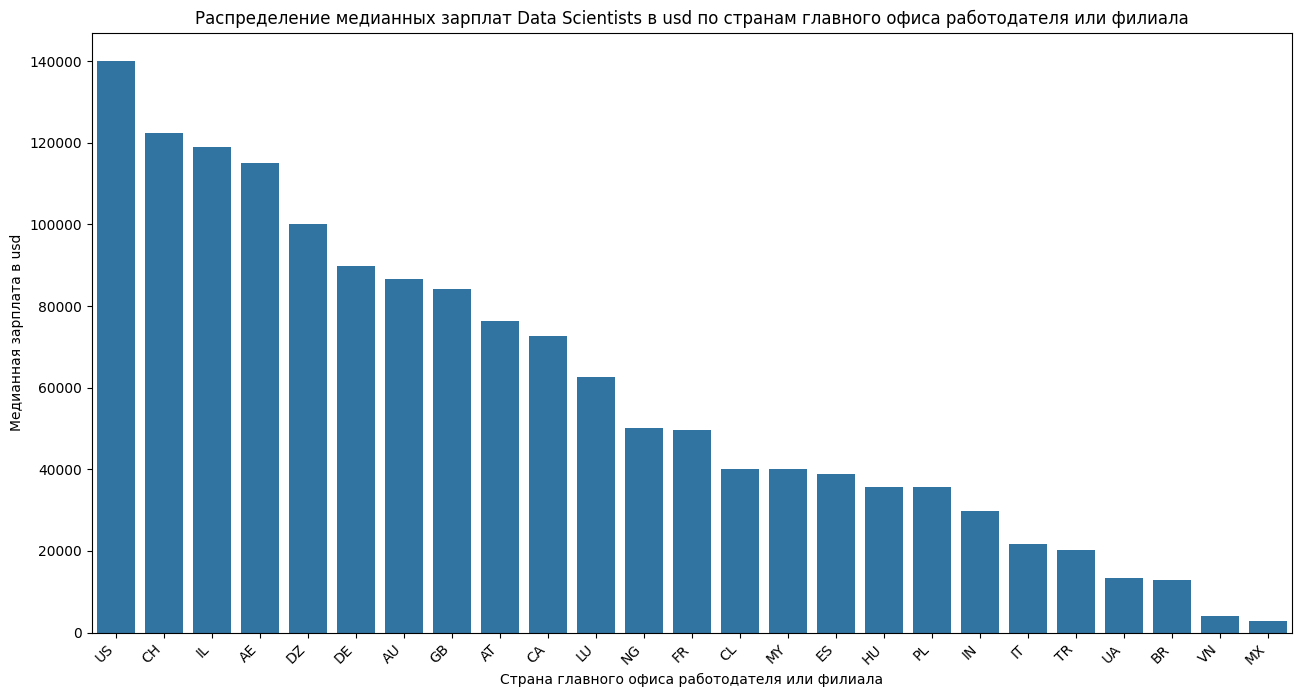

In [505]:
fig = plt.figure(figsize=(12, 6))
axes = fig.add_axes([0, 0, 1, 1])

data_scientists_company_location = data_scientists.groupby('company_location', observed=True)['salary_in_usd'].median().sort_values(ascending=False)
data_scientists_company_location = data_scientists_company_location[data_scientists_company_location > 0]

sns.barplot(x=data_scientists_company_location.index, y=data_scientists_company_location.values, ax=axes, order=data_scientists_company_location.index)
axes.tick_params(axis='x', labelrotation=45)
plt.setp(axes.get_xticklabels(), ha='right')
axes.set(xlabel='Страна главного офиса работодателя или филиала', ylabel='Медианная зарплата в usd')
axes.set_title('Распределение медианных зарплат Data Scientists в usd по странам главного офиса работодателя или филиала')

plt.show()

# Распределение размеров компаний

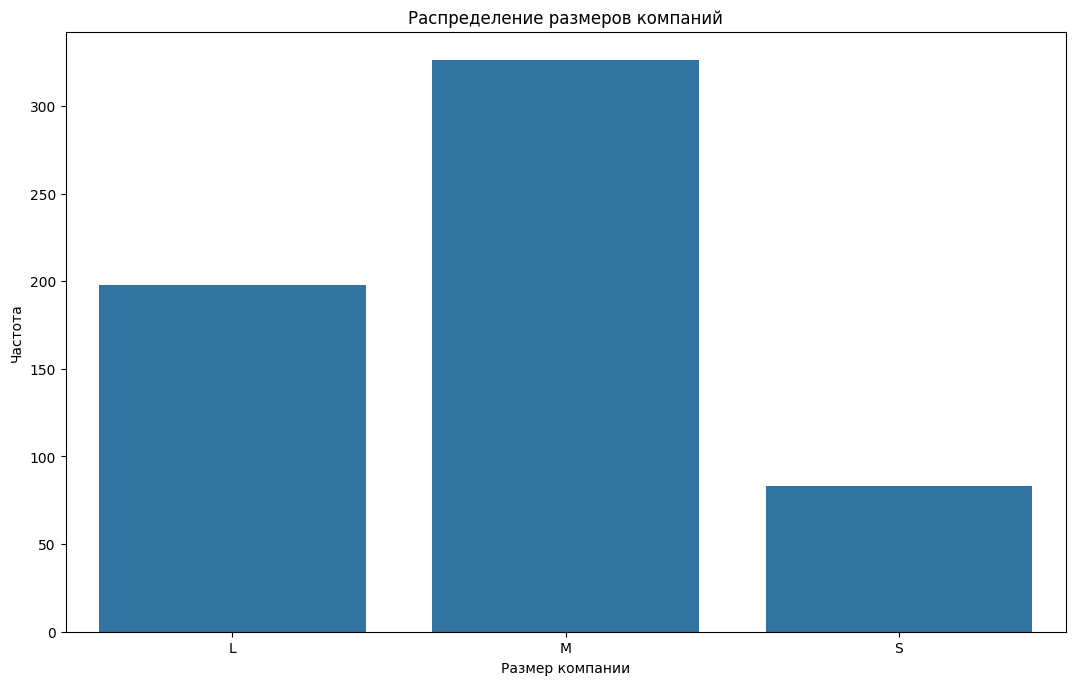

In [482]:
fig = plt.figure(figsize=(10, 6))
axes = fig.add_axes([0, 0, 1, 1])

sns.barplot(data=data['company_size'].value_counts(), ax=axes)
axes.set(xlabel='Размер компании', ylabel='Частота')
axes.set_title('Распределение размеров компаний')

plt.show()

In [483]:
company_size_stats = data['company_size'].value_counts(ascending=False)
print(f'Всего уникальных размеров компаний: {company_size_stats.shape[0]}')
print(f'Самый популярный размер компании: {company_size_stats.index[0]}')
display(company_size_stats)

Всего уникальных размеров компаний: 3
Самый популярный размер компании: M


company_size
M    326
L    198
S     83
Name: count, dtype: int64

# Зависимость зарплат Data Scientists в usd от размера компании

# Статистический тест
Проверим гипотезу зависимости зарплат Data Scientists от размера компании.  
H0: Распределения зарплат одинаковы для всех размеров компаний.  
H1: Хотя бы для оного размера компании распределение зарплат отличается.  

In [484]:
alpha = 0.05

company_sizes = data_scientists['company_size'].value_counts().index.to_list()
company_sizes_groups = [data_scientists[data_scientists['company_size'] == size]['salary_in_usd'] for size in company_sizes]

stat, p = kruskal(*company_sizes_groups)

print('p-value = {:.3f}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Построим визуализацию.

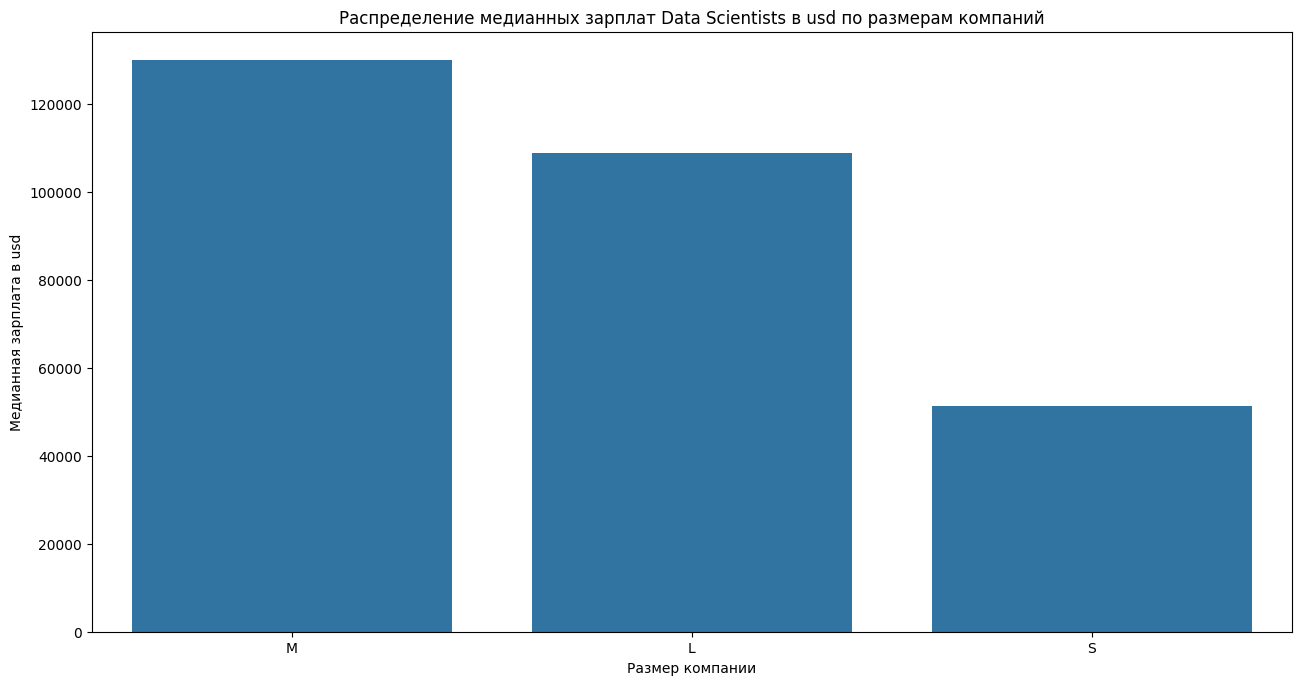

In [503]:
fig = plt.figure(figsize=(12, 6))
axes = fig.add_axes([0, 0, 1, 1])

data_scientists_company_size = data_scientists.groupby('company_size', observed=True)['salary_in_usd'].median().sort_values(ascending=False)
data_scientists_company_size = data_scientists_company_size[data_scientists_company_size > 0]

sns.barplot(x=data_scientists_company_size.index, y=data_scientists_company_size.values, ax=axes, order=data_scientists_company_size.index)
axes.set(xlabel='Размер компании', ylabel='Медианная зарплата в usd')
axes.set_title('Распределение медианных зарплат Data Scientists в usd по размерам компаний')

plt.show()

# Общие выводы

## Зарплаты
Средняя зп в долларах: 112297.87  
Медиана: 101570

## Общая выплаченная валовая сумма заработной платы
Среднее 324000 не отражает реальной картины. Так как стандартное отклонение равно 1544358. Что почти в 5 раз больше. Это значит в данных большой разброс. И есть выбросы, которые сильно искажают среднее. По графику видно, что большая часть валовых зп лежит в области 50-100 тыс.

## Количество вакансий
Заметна тенденция к росту вакансий с каждым годом. 
Причём с 2020 по 2021 год количество вакансий увеличилось более чем в 2 раза, а с 2021 по 2022 рост вакансий замедлился и составил меньше чем 2 раза.

## Уровень опыта
Наиболее распространённый уровень соискателей - Senior-level/Expert.  
Далее по убыванию идут Mid-level/Intermediate, Entry-level/Junior и Executive-level/Director.

## Тип трудоустройства
Не участвует в исследовании, поскольку это неинформативный признак (96.87% одинаковых значений).
<!-- Явный лидер: полный рабочий день.  
Остальные типы незначительны по количеству. -->

## Роли соискателей
Топ 5 ролей:  
* Data Scientist
* Data Engineer
* Data Analyst
* Machine Learning Engineer
* Research Scientist

## Работодатели
Безоговорочный лидер по числу главных офисов работодателя - США.  
По размеру компаний лидируют средние компании (от 50 до 250 сотрудников). Далее по убыванию крупные и небольшие.  

# Статистический анализ данных

Проверим гипотезу: Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?  
H0: Распределения зарплат для Data Scientist одинаковы для всех годов.  
H1: Хотя бы в одном году распределения зарплат отличаются.  

In [486]:
alpha = 0.05

years = data_scientists['work_year'].value_counts().index.to_list()
year_groups = [data_scientists[data_scientists['work_year'] == year]['salary_in_usd'] for year in years]

stat, p = kruskal(*year_groups)

print('p-value = {:.3f}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Построим визуализацию.

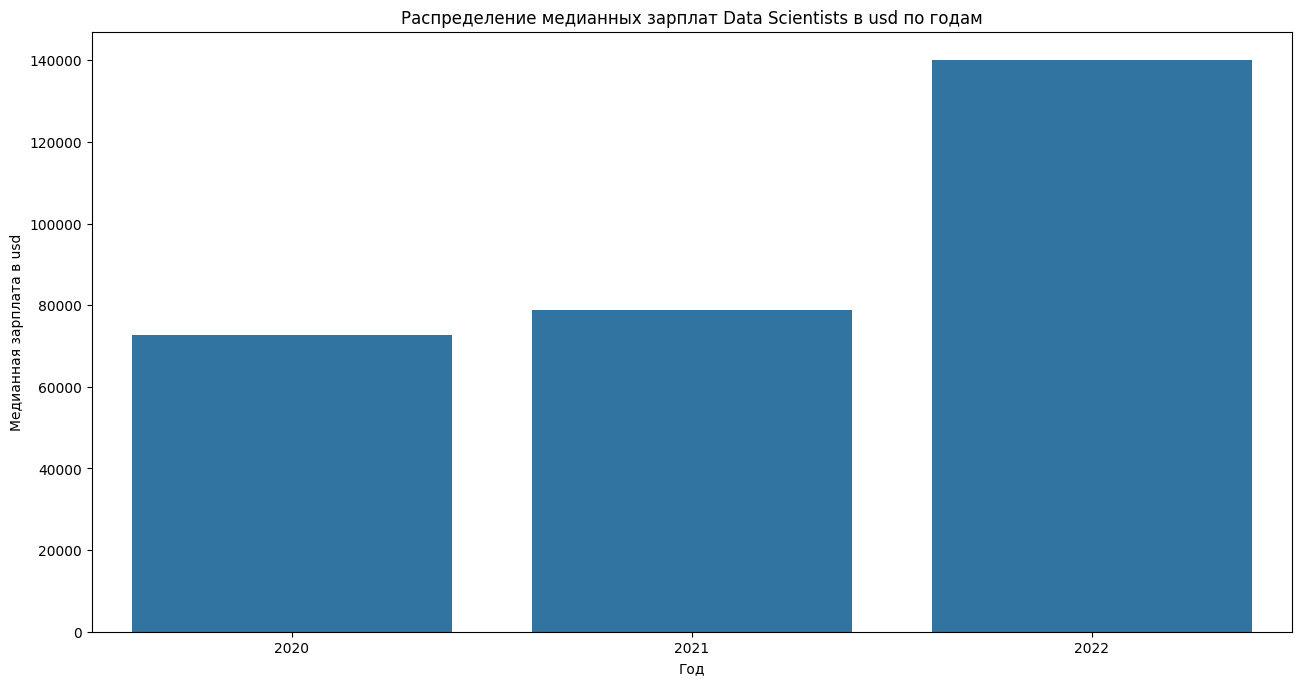

In [487]:
fig = plt.figure(figsize=(12, 6))
axes = fig.add_axes([0, 0, 1, 1])

data_scientists_year = data_scientists.groupby('work_year')['salary_in_usd'].median().sort_values(ascending=True)
sns.barplot(x=data_scientists_year.index, y=data_scientists_year.values, ax=axes, order=data_scientists_year.index)
axes.set(xlabel='Год', ylabel='Медианная зарплата в usd')
axes.set_title('Распределение медианных зарплат Data Scientists в usd по годам')

plt.show()

Статистический тест подтвердил, что различия есть в зарплатах Data Scientist для разных годов. Визуализация показала, что наблюдается устойчивый рост зарплат от года к году.

Гипотеза: Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?  
H0: Зарплаты Data Scientist и Data Engineer не отличаются статистически друг от друга.  
H1: Зарплаты Data Scientist и Data Engineer значимо отличаются статистически.  

In [491]:
alpha = 0.05

data_engineers = data[data['job_title'].str.contains('Data Engineer')]
data_scientists_salary_2022 = data_scientists[data_scientists['work_year'] == 2022]['salary_in_usd']
data_engineers_salary_2022 = data_engineers[data_engineers['work_year'] == 2022]['salary_in_usd']

stat, p = stats.mannwhitneyu(data_scientists_salary_2022, data_engineers_salary_2022)

print('p-value = {:.3f}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.076
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


Посчитаем медианы зарплат Data Scientist и Data Engineer для наглядного сравнения.

In [489]:
print('Медианная зарплата Data Scientists в 2022 году: ${:.2f}'.format(data_scientists_salary_2022.median()))
print('Медианная зарплата Data Engineers в 2022 году: ${:.2f}'.format(data_engineers_salary_2022.median()))

Медианная зарплата Data Scientists в 2022 году: $140000.00
Медианная зарплата Data Engineers в 2022 году: $119093.50


Несмотря на более высокую медианную зарплату Data Scientists в 2022 году, тест Манна-Уитни не выявил статистически значимых различий между распределениями зарплат (p = 0.076).  
Это может быть связано с большим разбросом значений и перекрытием распределений зарплат в двух группах.

Гипотеза: Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?   
H0: Наличие должностей Data Scientist и Data Engineer не зависит от размера компании.  
H1: Наличие должностей Data Scientist и Data Engineer зависит от размера компании. 

In [501]:
alpha = 0.05
data_scientists_and_engineers = data[data['job_title'].str.contains('Data Scientist|Data Engineer')].copy()
data_scientists_and_engineers['job_title'] = data_scientists_and_engineers['job_title'].cat.remove_unused_categories()

ct = pd.crosstab(data_scientists_and_engineers['company_size'], data_scientists_and_engineers['job_title'])

chi2, p, dof, expected = chi2_contingency(ct)

print('p-value = {:.2f}'.format(p))

if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))


p-value = 0.00
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Посчитаем остатки Пирсона, что бы увидеть картину получше.

In [502]:
expected = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

pearson_residuals = (ct - expected) / np.sqrt(expected)

pearson_residuals

job_title,Applied Data Scientist,Big Data Engineer,Cloud Data Engineer,Data Engineer,Data Engineering Manager,Data Scientist,Director of Data Engineering,Lead Data Engineer,Lead Data Scientist,Principal Data Engineer,Principal Data Scientist,Staff Data Scientist
company_size,,,,,,,,,,,,
L,2.598344,0.829420,0.414710,-1.016652,1.821292,-0.343771,0.414710,-0.700397,1.009499,1.009499,0.447487,-0.575526
M,-1.661401,-1.149834,-1.050762,1.889471,-1.661401,-0.218708,-0.099072,-1.270515,-1.286915,-0.509864,-0.439696,0.602892
S,-0.763935,1.103421,1.586576,-2.396570,0.545078,1.054756,-0.483155,3.942989,1.098186,-0.591741,0.202418,-0.341642


Анализ остатков Пирсона показал, что небольшие компании чаще нанимают Lead Data Engineer, тогда как обычные Data Engineer представлены реже ожидаемого.  
В средних компаниях наблюдается повышенная представленность Data Engineer, что может говорить о формировании инженерной культуры.  
В крупных компаниях чаще встречаются Applied Data Scientist, что может быть связано с более активным внедрением моделей машинного обучения в бизнес.  